### GITHUB REPO: https://github.com/MaartjePfauder/AnalysingData

In [1]:
import spacy
from spacy.cli import download
download("en_core_web_sm")
download("nl_core_news_sm")
download("de_core_news_sm")

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✔ Download and installation successful
You can now load the package via spacy.load('nl_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime

In [75]:
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize, wordpunct_tokenize, WhitespaceTokenizer
from nltk.stem import LancasterStemmer,PorterStemmer, WordNetLemmatizer
from nltk.corpus import wordnet
from nltk import pos_tag
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt
from spacy import displacy
import re
from spacy.util import filter_spans
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np
import matplotlib.pyplot as plt
from spacy.util import filter_spans
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report
)

## Part 1.1

In [20]:
folder_path = Path("Part_I_1-2")

# Dictionary to store word frequencies per story
word_frequencies = {}

# Counter for total frequencies
total_word_frequencies = Counter()

# store tokens and sentences per story
story_tokens = {}
story_sentences = {}

# Iterate over all stories
for file_path in folder_path.glob("*.txt"):  
    with open(file_path, "r", encoding="utf-8") as f:
        text = f.read()  
    
    # Sentence splitting / word tokenization
    sentences = sent_tokenize(text)
    words = []
    for sentence in sentences:
        words.extend(word_tokenize(sentence))

    # save for later reuse
    story_sentences[file_path.name] = sentences
    story_tokens[file_path.name] = words
    
    # Compute frequency story and store in dictionary
    word_counts = Counter(words)
    word_frequencies[file_path.name] = dict(word_counts)
    
    # Update total frequencies
    total_word_frequencies.update(word_counts)

word_frequencies["TOTAL"] = dict(total_word_frequencies)

In [21]:
# Statistics per story

for story in word_frequencies:
    
    if story == "TOTAL":
        continue
    
    print("\n" + story)
    
    freq_dict = word_frequencies[story]
    
    print("Total words:", sum(freq_dict.values()))
    print("Unique words:", len(freq_dict))
    
    print("Most common words:")
    print(Counter(freq_dict).most_common(25))


# Total statistis

print("TOTAL")

total_dict = word_frequencies["TOTAL"]

print("Total words:", sum(total_dict.values()))
print("Unique words:", len(total_dict))

print("Most common words overall:")
print(Counter(total_dict).most_common(25))


01.txt
Total words: 352
Unique words: 164
Most common words:
[(',', 30), ('the', 14), ('her', 12), ('River', 11), ('Missy', 10), ('a', 10), ('.', 10), ('and', 9), ('to', 8), ('was', 7), ('on', 7), ('“', 6), ('”', 6), ('maps', 5), ('at', 5), ('’', 5), ('it', 4), ('over', 4), ('s', 4), ('?', 3), ('sitting', 3), ('chair', 3), ('had', 3), ('The', 3), ('that', 3)]

02.txt
Total words: 779
Unique words: 292
Most common words:
[(',', 74), ('she', 52), ('’', 25), ('the', 20), ('her', 20), ('.', 19), ('him', 16), ('t', 15), ('and', 14), ('to', 13), ('in', 12), ('She', 12), ('he', 12), ('was', 12), ('a', 11), ('as', 11), ('d', 8), ('had', 8), ('how', 7), ('of', 7), ('back', 6), ('with', 6), ('it', 6), ('who', 5), ('didn', 5)]

03.txt
Total words: 2435
Unique words: 702
Most common words:
[('.', 160), (',', 105), ('the', 64), ('to', 55), ('her', 53), ("''", 51), ('``', 47), ('and', 47), ('you', 37), ('I', 35), ('he', 32), ('of', 30), ('his', 28), ('was', 27), ('Rose', 25), ('a', 24), ('He', 24),

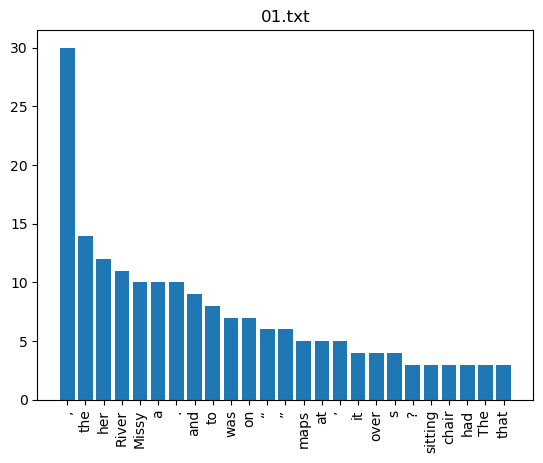

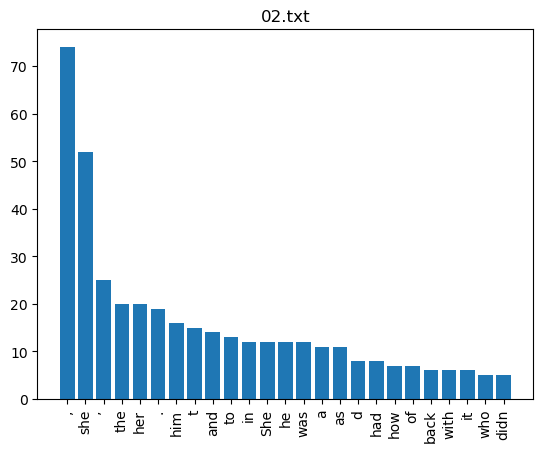

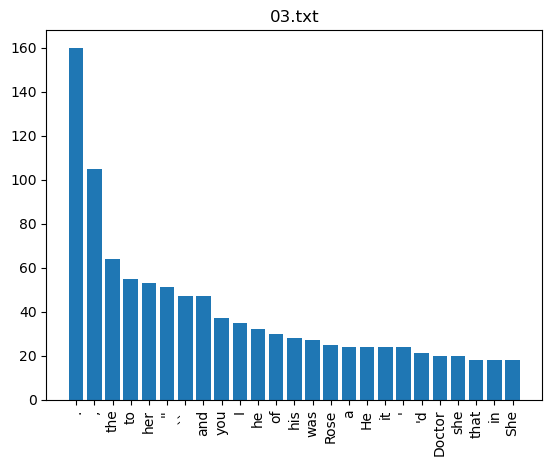

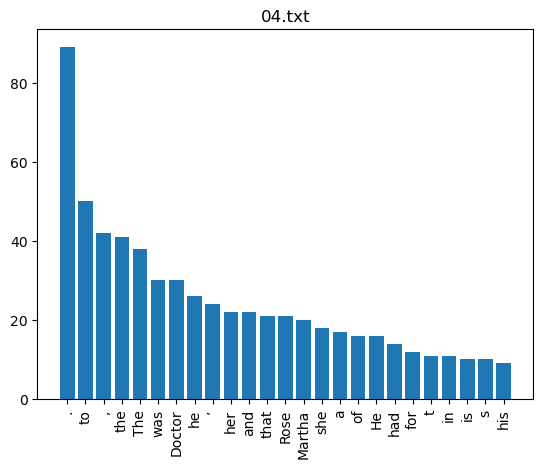

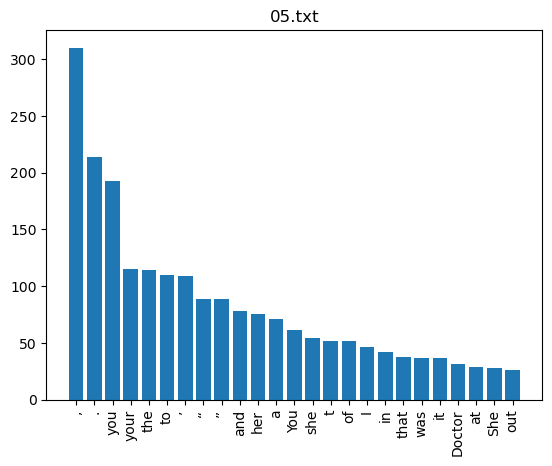

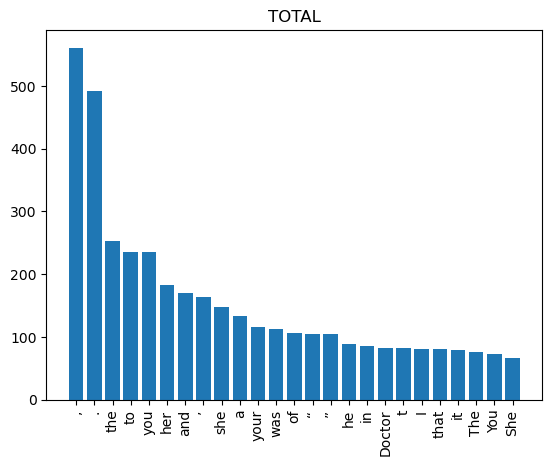

In [22]:
for story, freq_dict in word_frequencies.items():
    
    common_words = Counter(freq_dict).most_common(25)
    
    words = [word for word, freq in common_words]
    frequencies = [freq for word, freq in common_words]
    
    plt.figure()
    plt.bar(words, frequencies)
    plt.xticks(rotation=90)
    plt.title(story)
    plt.show()

## Part 1.2

In [23]:
#Porter stemming frequencies + statistics
porter = PorterStemmer()

porter_frequencies = {}
porter_total = Counter()   # ← this must exist before using it

for story, words in story_tokens.items():
    porter_stems = [porter.stem(w) for w in words]
    counts = Counter(porter_stems)
    porter_frequencies[story] = dict(counts)
    porter_total.update(counts)

porter_frequencies["TOTAL"] = dict(porter_total)

# ---- statistics ----
for story in porter_frequencies:
    if story == "TOTAL":
        continue

    print("\nPORTER:", story)
    freq_dict = porter_frequencies[story]
    print("Total stems:", sum(freq_dict.values()))
    print("Unique stems:", len(freq_dict))
    print("Most common stems:")
    print(Counter(freq_dict).most_common(10))

print("\nPORTER: TOTAL")
print("Total stems:", sum(porter_total.values()))
print("Unique stems:", len(porter_total))
print("Most common stems overall:")
print(porter_total.most_common(20))


PORTER: 01.txt
Total stems: 352
Unique stems: 149
Most common stems:
[(',', 30), ('the', 17), ('her', 12), ('river', 11), ('missi', 10), ('a', 10), ('.', 10), ('and', 9), ('to', 8), ('wa', 7)]

PORTER: 02.txt
Total stems: 779
Unique stems: 269
Most common stems:
[(',', 74), ('she', 64), ('’', 25), ('her', 21), ('the', 20), ('.', 19), ('him', 16), ('t', 15), ('and', 14), ('to', 13)]

PORTER: 03.txt
Total stems: 2435
Unique stems: 595
Most common stems:
[('.', 160), (',', 105), ('the', 80), ('her', 57), ('he', 56), ('to', 55), ("''", 51), ('you', 47), ('``', 47), ('and', 47)]

PORTER: 04.txt
Total stems: 1325
Unique stems: 376
Most common stems:
[('.', 89), ('the', 79), ('to', 50), (',', 42), ('he', 42), ('wa', 30), ('doctor', 30), ('she', 25), ('her', 24), ('’', 24)]

PORTER: 05.txt
Total stems: 4676
Unique stems: 962
Most common stems:
[(',', 310), ('you', 254), ('.', 214), ('the', 133), ('your', 124), ('to', 112), ('’', 109), ('“', 89), ('”', 89), ('and', 84)]

PORTER: TOTAL
Total st

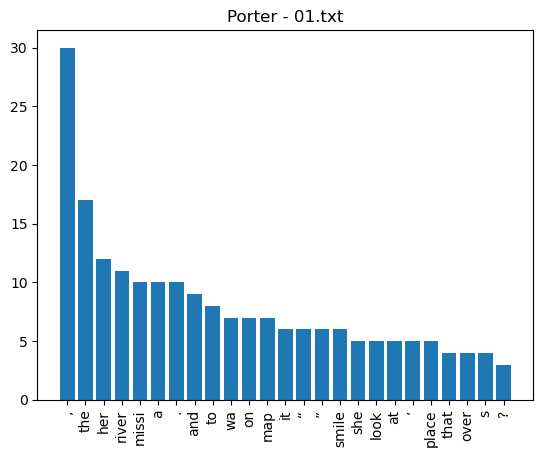

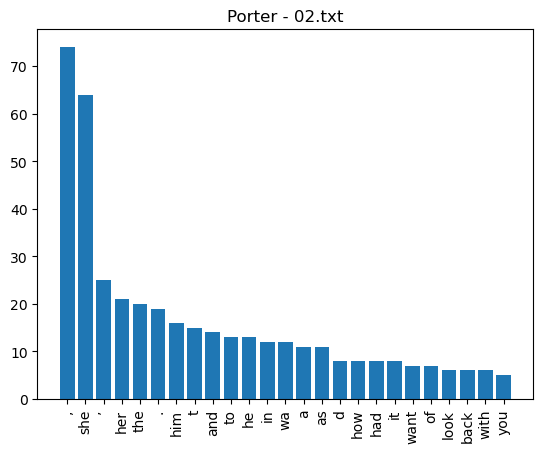

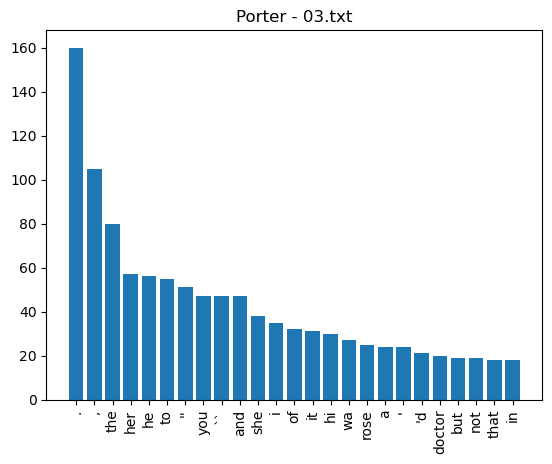

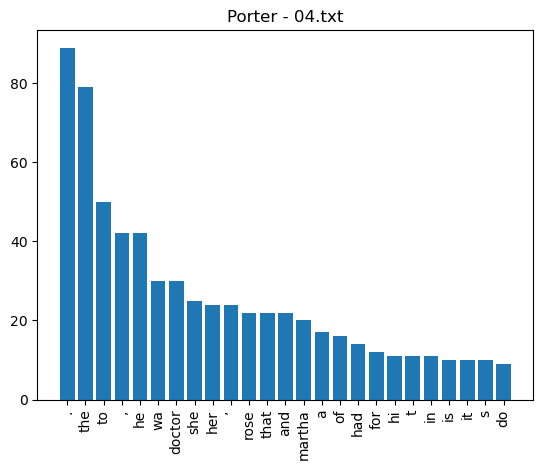

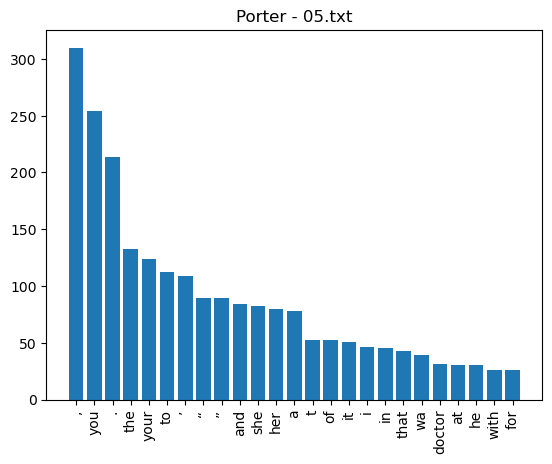

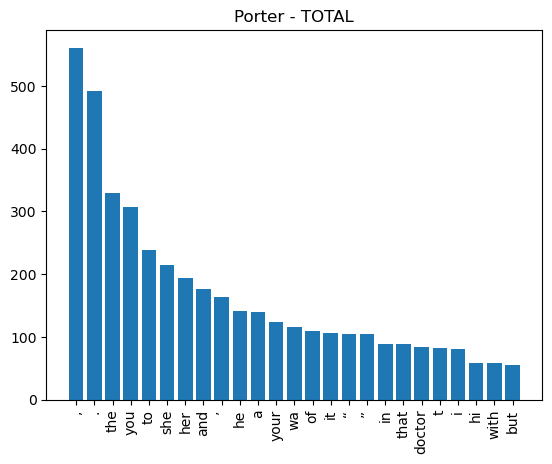

In [24]:
# Recreate plot Porter stemmer
for story, freq_dict in porter_frequencies.items():
    
    common = Counter(freq_dict).most_common(25)
    
    words = [w for w, f in common]
    freqs = [f for w, f in common]
    
    plt.figure()
    plt.bar(words, freqs)
    plt.xticks(rotation=90)
    plt.title("Porter - " + story)
    plt.show()

In [25]:
lancaster = LancasterStemmer()

lancaster_frequencies = {}
lancaster_total = Counter()

for story, words in story_tokens.items():
    lancaster_stems = [lancaster.stem(w) for w in words]
    counts = Counter(lancaster_stems)
    lancaster_frequencies[story] = dict(counts)
    lancaster_total.update(counts)

lancaster_frequencies["TOTAL"] = dict(lancaster_total)

# statistics output
for story in lancaster_frequencies:
    if story == "TOTAL":
        continue

    print("\nLANCASTER:", story)
    freq_dict = lancaster_frequencies[story]
    print("Total stems:", sum(freq_dict.values()))
    print("Unique stems:", len(freq_dict))
    print("Most common stems:")
    print(Counter(freq_dict).most_common(10))

print("\nLANCASTER: TOTAL")
total_dict = lancaster_frequencies["TOTAL"]
print("Total stems:", sum(total_dict.values()))
print("Unique stems:", len(total_dict))
print("Most common stems overall:")
print(Counter(total_dict).most_common(20))


LANCASTER: 01.txt
Total stems: 352
Unique stems: 149
Most common stems:
[(',', 30), ('the', 17), ('her', 12), ('riv', 11), ('missy', 10), ('a', 10), ('.', 10), ('and', 9), ('to', 8), ('was', 7)]

LANCASTER: 02.txt
Total stems: 779
Unique stems: 264
Most common stems:
[(',', 74), ('she', 64), ('’', 25), ('her', 23), ('the', 20), ('.', 19), ('him', 16), ('t', 15), ('and', 14), ('to', 13)]

LANCASTER: 03.txt
Total stems: 2435
Unique stems: 579
Most common stems:
[('.', 160), (',', 105), ('the', 80), ('her', 57), ('he', 56), ('to', 55), ("''", 51), ('you', 47), ('``', 47), ('and', 47)]

LANCASTER: 04.txt
Total stems: 1325
Unique stems: 364
Most common stems:
[('.', 89), ('the', 79), ('to', 50), (',', 42), ('he', 42), ('was', 30), ('doct', 30), ('she', 25), ('her', 25), ('’', 24)]

LANCASTER: 05.txt
Total stems: 4676
Unique stems: 920
Most common stems:
[(',', 310), ('you', 254), ('.', 214), ('the', 133), ('yo', 124), ('to', 112), ('’', 109), ('“', 89), ('”', 89), ('and', 84)]

LANCASTER: 

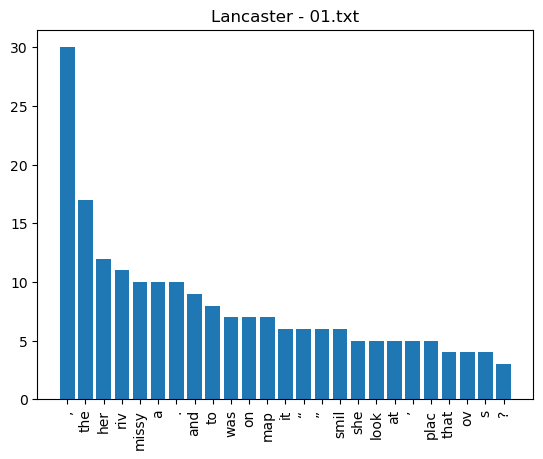

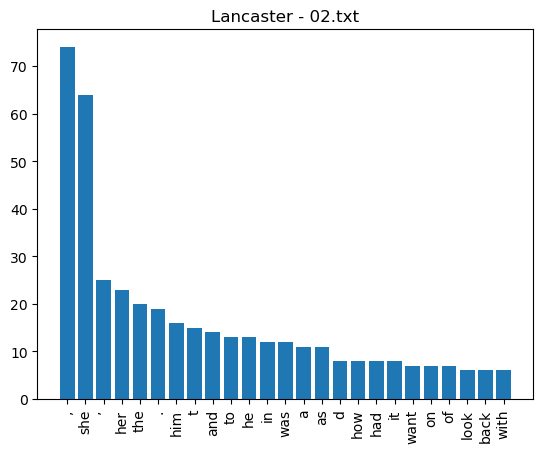

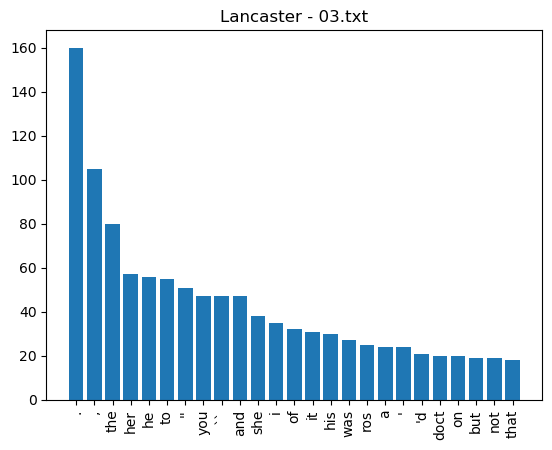

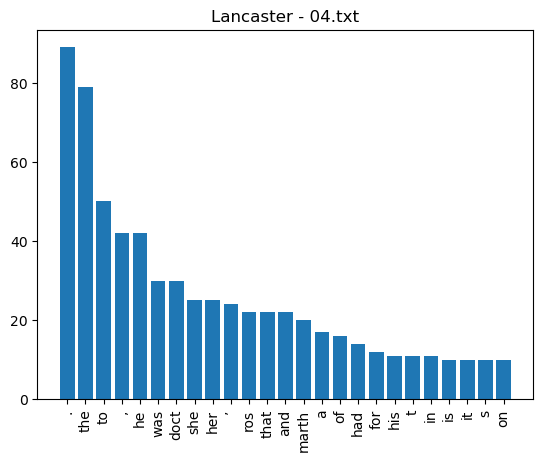

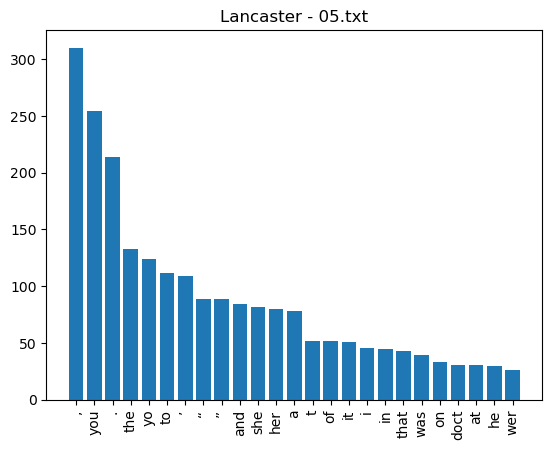

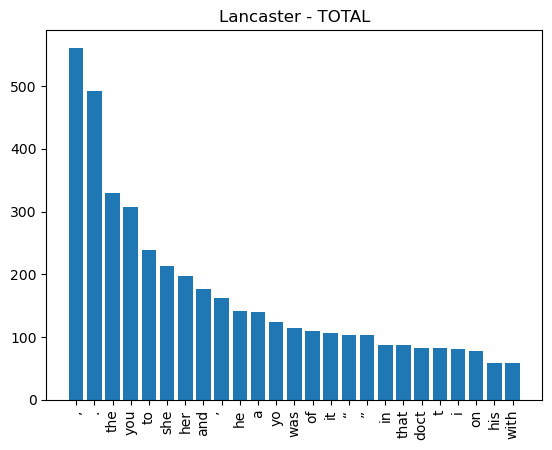

In [26]:
for story, freq_dict in lancaster_frequencies.items():
    
    common = Counter(freq_dict).most_common(25)
    
    words = [w for w, f in common]
    freqs = [f for w, f in common]
    
    plt.figure()
    plt.bar(words, freqs)
    plt.xticks(rotation=90)
    plt.title("Lancaster - " + story)
    plt.show()

### DISCUSSION RESULTS

TOTAL unique words:
Unstemmed: 1842
Porter: 1446
Lancaster: 1359

* Stemming reduces vocabulary size.
* Porter reduces it a bit, keeps stems more readable (river, run, maximum)
* Lancaster reduces it more, produces shorter stems (doct, riv, yo). It merges more word forms but sometimes loses meaning.
* Punctuation dominates everywhere. Maybe remove next time?


## Part 1.3

In [27]:
folder_path = Path("Part_I_3")

def clean_gutenberg(text):
    # keep only text inside START/END markers
    start_marker = "*** START OF THE PROJECT GUTENBERG EBOOK"
    end_marker = "*** END OF THE PROJECT GUTENBERG EBOOK"

    if start_marker in text:
        text = text.split(start_marker, 1)[1]
    if end_marker in text:
        text = text.split(end_marker, 1)[0]

    # start with first real chapter (not TOC)
    if "\nCHAPTER I\n" in text:   
        text = text.split("\nCHAPTER I\n", 1)[1]
        text = "CHAPTER I\n" + text

    elif "\nHOOFDSTUK I.\n" in text:
        text = text.split("\nHOOFDSTUK I.\n", 1)[1]
        text = "HOOFDSTUK I.\n" + text

    elif "\nErstes Kapitel.\n" in text:
        text = text.split("\nErstes Kapitel.\n", 1)[1]
        text = "Erstes Kapitel.\n" + text

    return text.strip()

cleaned_documents = {}

for file_path in folder_path.glob("*.txt"):
    with open(file_path, "r", encoding="utf-8") as f:
        raw = f.read()
    cleaned_documents[file_path.name] = clean_gutenberg(raw)

# store in variables
english_tom = cleaned_documents.get("pg74.txt", "")
dutch_tom   = cleaned_documents.get("pg18381.txt", "")
german_tom  = cleaned_documents.get("pg30165.txt", "")

In [28]:
print(english_tom)
print("\n --------------------------------------------------------------------------------------\n")
print(dutch_tom)
print("\n --------------------------------------------------------------------------------------\n")
print(german_tom)

CHAPTER I


“Tom!”

No answer.

“TOM!”

No answer.

“What’s gone with that boy, I wonder? You TOM!”

No answer.

The old lady pulled her spectacles down and looked over them about the
room; then she put them up and looked out under them. She seldom or
never looked _through_ them for so small a thing as a boy; they were
her state pair, the pride of her heart, and were built for “style,” not
service—she could have seen through a pair of stove-lids just as well.
She looked perplexed for a moment, and then said, not fiercely, but
still loud enough for the furniture to hear:

“Well, I lay if I get hold of you I’ll—”

She did not finish, for by this time she was bending down and punching
under the bed with the broom, and so she needed breath to punctuate the
punches with. She resurrected nothing but the cat.

“I never did see the beat of that boy!”

She went to the open door and stood in it and looked out among the
tomato vines and “jimpson” weeds that constituted the garden. No Tom. So
she 

In [29]:
# Process texts
doc_en = nlp_en(english_tom)
doc_nl = nlp_nl(dutch_tom)
doc_de = nlp_de(german_tom)

# Extract POS tags (token, POS)
pos_en = [(token.text, token.pos_) for token in doc_en]
pos_nl = [(token.text, token.pos_) for token in doc_nl]
pos_de = [(token.text, token.pos_) for token in doc_de]

# Show first 30 tags of each
print("English:")
print(pos_en[:30])

print("\nDutch:")
print(pos_nl[:30])

print("\nGerman:")
print(pos_de[:30])

English:
[('CHAPTER', 'PROPN'), ('I', 'PRON'), ('\n\n\n', 'SPACE'), ('“', 'PUNCT'), ('Tom', 'PROPN'), ('!', 'PUNCT'), ('”', 'PUNCT'), ('\n\n', 'SPACE'), ('No', 'DET'), ('answer', 'NOUN'), ('.', 'PUNCT'), ('\n\n', 'SPACE'), ('“', 'PUNCT'), ('TOM', 'PROPN'), ('!', 'PUNCT'), ('”', 'PUNCT'), ('\n\n', 'SPACE'), ('No', 'DET'), ('answer', 'NOUN'), ('.', 'PUNCT'), ('\n\n', 'SPACE'), ('“', 'PUNCT'), ('What', 'PRON'), ('’s', 'AUX'), ('gone', 'VERB'), ('with', 'ADP'), ('that', 'DET'), ('boy', 'NOUN'), (',', 'PUNCT'), ('I', 'PRON')]

Dutch:
[('HOOFDSTUK', 'PROPN'), ('I.', 'PROPN'), ('\n\n\n', 'SPACE'), ('"', 'PUNCT'), ('Tom', 'PROPN'), ('!', 'SYM'), ('"', 'PUNCT'), ('\n\n', 'SPACE'), ('Geen', 'DET'), ('antwoord', 'NOUN'), ('.', 'PUNCT'), ('\n\n', 'SPACE'), ('"', 'PUNCT'), ('Tom', 'PROPN'), ('!', 'SYM'), ('"', 'PUNCT'), ('\n\n', 'SPACE'), ('Geen', 'DET'), ('antwoord', 'NOUN'), ('.', 'PUNCT'), ('\n\n', 'SPACE'), ('"', 'PUNCT'), ('Waar', 'ADV'), ('zou', 'AUX'), ('die', 'DET'), ('drommelsche', 'ADJ'),

In [30]:
# Extract only the POS tag
pos_freq_en = Counter([pos for word, pos in pos_en])
pos_freq_nl = Counter([pos for word, pos in pos_nl])
pos_freq_de = Counter([pos for word, pos in pos_de])

print("English POS frequencies:")
print(pos_freq_en)

print("\nDutch POS frequencies:")
print(pos_freq_nl)

print("\nGerman POS frequencies:")
print(pos_freq_de)

English POS frequencies:
Counter({'PUNCT': 15310, 'NOUN': 12144, 'VERB': 11292, 'PRON': 10268, 'ADP': 7258, 'DET': 6856, 'SPACE': 6393, 'ADV': 4883, 'ADJ': 4404, 'AUX': 4377, 'CCONJ': 3840, 'PROPN': 3010, 'PART': 2085, 'SCONJ': 1805, 'NUM': 639, 'INTJ': 475, 'X': 73, 'SYM': 1})

Dutch POS frequencies:
Counter({'PUNCT': 13947, 'NOUN': 11920, 'VERB': 11768, 'PRON': 10021, 'ADP': 8793, 'SPACE': 7216, 'DET': 7114, 'ADV': 5761, 'ADJ': 5048, 'AUX': 3839, 'CCONJ': 3503, 'PROPN': 3474, 'SCONJ': 1999, 'NUM': 391, 'INTJ': 365, 'SYM': 353, 'X': 23})

German POS frequencies:
Counter({'PUNCT': 18397, 'NOUN': 11099, 'VERB': 9468, 'ADV': 9266, 'PRON': 8771, 'DET': 7449, 'SPACE': 6630, 'ADP': 5268, 'AUX': 3740, 'CCONJ': 3356, 'ADJ': 2914, 'PROPN': 2181, 'PART': 1679, 'SCONJ': 1514, 'NUM': 309, 'X': 221, 'INTJ': 208})


### DISCUSSION RESULTS

English
* Balanced noun/verb usage
* Heavy use of pronouns
* Frequent auxiliary verbs

Dutch
* Slightly more verbs (still balanced noun/verb usage)
* Slightly more determiners
* Closest to English distribution

German
* More adverbs
* More determiners
* Fewer pronouns
* Fewer verbs (more noun heavy than Dutch and English)
* More morphologically dense language (more descriptive?)

No proof: Differences could also result from translation choices made by the translators.

## Part 2

In [33]:
folder_path = Path("Part_I_1-2")
nlp = spacy.load("en_core_web_sm")

story_texts = {}
for file_path in folder_path.glob("*.txt"):
    with open(file_path, "r", encoding="utf-8") as f:
        story_texts[file_path.name] = f.read()

story_docs = {name: nlp(text) for name, text in story_texts.items()}

In [36]:
for name, doc in story_docs.items():
    print(f"\n{name}")
    displacy.render(doc, style="ent", jupyter=True)


01.txt



02.txt



03.txt



04.txt



05.txt


In [46]:
# Select sentences with many entities
selected_sentences = {}

for name, doc in story_docs.items():
    # Try sentences with three or more entities
    sents_3 = [sent for sent in doc.sents if len(sent.ents) >= 3]
    
    if sents_3:
        chosen = sents_3[:2] 
    else:
        # If 3+ entities don't exist, look for 2
        sents_2 = [sent for sent in doc.sents if len(sent.ents) >= 2]
        chosen = sents_2[:2]
    
    selected_sentences[name] = [sent.text for sent in chosen]

In [48]:
# Print entities
for name, sentences in selected_sentences.items():
    print(f"\nStory: {name}")
    for sent in sentences:
        doc = nlp(sent)
        print("\nSentence:")
        print(sent)
        print("Predicted entities:")
        print([(ent.text, ent.label_) for ent in doc.ents])


Story: 01.txt

Sentence:
She was wearing a t-shirt that drenched her form, and some trousers that looked about the right size, Missy smiled, still in her Mary Poppins looking outfit, River looked over at the maps.
Predicted entities:
[('Missy', 'PERSON'), ('Mary Poppins', 'PERSON'), ('River', 'LOC')]

Sentence:
Missy smiles and leans back, placing a kiss on River’s jaw, a smile on her face, River reaches onto the table for a cup of coffee, gracefully sitting herself on the chair next to Missy, she raises the cups to her lips, wondering wether Missy had noticed yet.
Predicted entities:
[('River', 'PRODUCT'), ('River', 'LOC'), ('Missy', 'PERSON'), ('Missy', 'PERSON')]

Story: 02.txt

Sentence:
She wished it could have been him after he knew who she was, because what he was mostly talking about was 1969, she wanted to know how her parents were in New York, she wanted the more mature version of him, but she lent against him, sitting in the garden, gently pulling him up to show him the thr

In [68]:
# Manual corrections
manual_annotations = {
    "01.txt": [
        {
            "sentence": "She was wearing a t-shirt that drenched her form, and some trousers that looked about the right size, Missy smiled, still in her Mary Poppins looking outfit, River looked over at the maps.",
            "entities": [
                ('Missy', 'PERSON'), ('Mary Poppins', 'PERSON'), ('River', 'PERSON')
            ]
        },
        {
            "sentence": "Missy smiles and leans back, placing a kiss on River’s jaw, a smile on her face, River reaches onto the table for a cup of coffee, gracefully sitting herself on the chair next to Missy, she raises the cups to her lips, wondering wether Missy had noticed yet.",
            "entities": [
                ('River', 'PERSON'), ('River', 'PERSON'), ('Missy', 'PERSON'), ('Missy', 'PERSON')
            ]
        }
     ],
    "02.txt": [
        {
            "sentence": "She wished it could have been him after he knew who she was, because what he was mostly talking about was 1969, she wanted to know how her parents were in New York, she wanted the more mature version of him, but she lent against him, sitting in the garden, gently pulling him up to show him the three children she had been left with, it wasn’t night yet.",
            "entities": [
                ('1969', 'DATE'), ('New York', 'GPE'), ('three', 'CARDINAL')
             ]
        },
        {
            "sentence": "She wished he’d let her data-ghost go, this felt the same as her life, except she couldn’t adventure on her own, she relied on him for a sense of adventure, she looked down at the diary, she needed a distraction, and as always in the library, as she wanted it happened, one of the three children pushed the door open and River smiled a bit, holding them in her arms, whispering stories of adventures.",
            "entities": [
                ('one', 'CARDINAL'), ('three', 'CARDINAL'), ('River', 'PERSON')
            ]
        }
     ],
    "03.txt": [
        {
            "sentence": "Two hearts beat in near panic, two hearts sting with the energy building for his body to burn, two hearts that would beat for Rose Tyler-",
            "entities": [
                ('Two', 'CARDINAL'), ('two', 'CARDINAL'), ('two', 'CARDINAL'), ('Rose Tyler', 'PERSON')
             ]
        },
        {
            "sentence": "The TARDIS, the Vortex, and I.\" Rose said, the echoes much more muted now.",
            "entities": [
                ('The TARDIS', 'TITLE'), ('the Vortex', 'TITLE')
            ]
        }
     ],
    "04.txt": [
        {
            "sentence": "One of the first things that Martha had noticed about The Doctor was how melancholic he was.",
            "entities": [
               ('One', 'CARDINAL'), ('first', 'ORDINAL'), ('Martha', 'PERSON'), ('The Doctor', 'TITLE')
             ]
        },
        {
            "sentence": "Martha knew almost nothing about Rose except for her name and what she didn’t have in common with Martha.",
            "entities": [
                ('Martha', 'PERSON'), ('Rose', 'PERSON'), ('Martha', 'PERSON')
            ]
        }
     ],
    "05.txt": [
        {
            "sentence": "Days turned into weeks.",
            "entities": [
                ('Days', 'DATE'), ('weeks', 'DATE')
             ]
        },
        {
            "sentence": "The Torvash laughed, \“Not so cheeky now, are you, Time Lord? F-fuck y-you!\”",
            "entities": [
                ('The Torvash', 'TITLE'), ('Time Lord', 'TITLE')
            ]
        }
     ]
}


In [82]:
""" I creaeted this function with some help of AI """
def spans_from_manual(text, entities, nlp):
    doc = nlp(text)
    spans = []
    cursor = 0 

    for ent_text, label in entities:
        m = re.search(re.escape(ent_text), text[cursor:])
        if not m:
            continue
        start = cursor + m.start()
        end = cursor + m.end()
        cursor = end 
        span = doc.char_span(start, end, label=label, alignment_mode="expand")
        if span is not None:
            spans.append(span)
    spans = filter_spans(spans)
    doc.ents = spans
    return doc

for story, items in manual_annotations.items():
    print(f"\nStory: {story}")
    for item in items:
        doc = spans_from_manual(item["sentence"], item["entities"], nlp)
        displacy.render(doc, style="ent", jupyter=True)


Story: 01.txt



Story: 02.txt



Story: 03.txt



Story: 04.txt



Story: 05.txt


### Performance

In [79]:
"""I created the below mentionned functions with some help of AI""" 

# Create gold standard spaCy Doc object from manual annotations
def make_gold_doc(text, entities):
    doc = nlp(text)
    spans = []
    cursor = 0

    for ent_text, label in entities:
        m = re.search(re.escape(ent_text), text[cursor:])
        if not m:
            continue
        start = cursor + m.start()
        end = cursor + m.end()
        cursor = end

        span = doc.char_span(start, end, label=label, alignment_mode="expand")
        if span:
            spans.append(span)

    doc.ents = filter_spans(spans)
    return doc

# Return token level NER tags
def token_tags(doc):
    return [
        "O" if t.ent_iob_ == "O" else f"{t.ent_iob_}-{t.ent_type_}"
        for t in doc
    ]

In [85]:
# Build y_true / y_pred
y_true, y_pred = [], []

for story, items in manual_annotations.items():
    for item in items:
        text = item["sentence"]
        gold = make_gold_doc(text, item["entities"])
        pred = nlp(text)
        y_true += token_tags(gold)
        y_pred += token_tags(pred)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

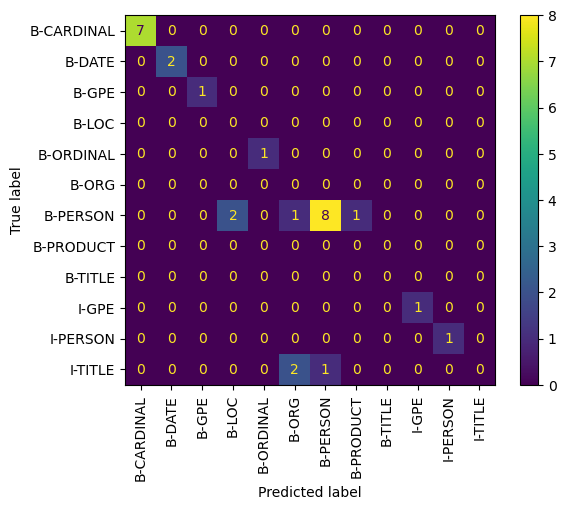

Accuracy: 0.9521276595744681
Precision (macro): 0.5740740740740741
Recall (macro):    0.48183760683760685
F1 (macro):        0.5161616161616162
Precision (micro): 0.7241379310344828
Recall (micro):    0.5526315789473685
F1 (micro):        0.6268656716417911
F1 (weighted):     0.610207336523126
              precision    recall  f1-score   support

  B-CARDINAL       1.00      1.00      1.00         7
      B-DATE       1.00      0.67      0.80         3
       B-GPE       1.00      1.00      1.00         1
       B-LOC       0.00      0.00      0.00         0
   B-ORDINAL       1.00      1.00      1.00         1
       B-ORG       0.00      0.00      0.00         0
    B-PERSON       0.89      0.62      0.73        13
   B-PRODUCT       0.00      0.00      0.00         0
     B-TITLE       0.00      0.00      0.00         5
       I-GPE       1.00      1.00      1.00         1
    I-PERSON       1.00      0.50      0.67         2
     I-TITLE       0.00      0.00      0.00         5

 

In [86]:
cm = confusion_matrix(y_true, y_pred, labels=labels_no_o)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_no_o)
disp.plot(xticks_rotation=90)
plt.show()

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision (macro):", precision_score(y_true, y_pred, average="macro", labels=labels_no_o, zero_division=0))
print("Recall (macro):   ", recall_score(y_true, y_pred, average="macro", labels=labels_no_o, zero_division=0))
print("F1 (macro):       ", f1_score(y_true, y_pred, average="macro", labels=labels_no_o, zero_division=0))

print("Precision (micro):", precision_score(y_true, y_pred, average="micro", labels=labels_no_o, zero_division=0))
print("Recall (micro):   ", recall_score(y_true, y_pred, average="micro", labels=labels_no_o, zero_division=0))
print("F1 (micro):       ", f1_score(y_true, y_pred, average="micro", labels=labels_no_o, zero_division=0))

print("F1 (weighted):    ", f1_score(y_true, y_pred, average="weighted", labels=labels_no_o, zero_division=0))

print(classification_report(y_true, y_pred, labels=labels_no_o, zero_division=0))

### Conclusion

* The automatic NER system shows OK performance on the manually annotated dataset.
* Overall accuracy is high (0.95), but probably due to correctly identifying non-entity tokens.
* The micro-averaged F1-score of 0.63 shows OK overall entity detection
* Lower macro F1-score of 0.52 suggests weaker performance on less frequent entity types.
* The model performs well on common categories such as PERSON, DATE, and CARDINAL, but not with TITLE. But I added title, was it OK that I did that?
